
# COMP8420 Assignment 1 — Text Classification for Fantasy Novels

### ID - 49128299

This project develops a full pipeline for classifying human-written and machine-generated fantasy text.



### Libraries




In [1]:
!pip install ebooklib beautifulsoup4 ftfy scikit-learn torch matplotlib pandas numpy transformers


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import os
import re
import math
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


c:\Users\royay\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


# Dataset


### Dataset design

This project uses a proprietary dataset built from two sources:

- **Human-written text (label = 0):** paragraphs sampled from three fantasy novels.
- **Machine-generated text (label = 1):** fantasy-style paragraphs stored in a separate CSV.

The final dataset is then shuffled and split into train / validation / test partitions.


In [3]:
# Dataset configuration

BOOKS = [
    ('AGameOfThrones.epub', 'A Game of Thrones'),
    ('TheNameoftheWind.epub', 'The Name of the Wind'),
    ('TheLiesofLockeLamora.epub', 'The Lies of Locke Lamora'),
]

HUMAN_OUTPUT_CSV = 'fantasy_human_dataset_3000.csv'
AI_DATASET_CSV = 'AI_dataset.csv'  # treated as machine-generated text
FINAL_DATASET_CSV = 'final_dataset.csv'

SAMPLES_PER_BOOK = 1000
MIN_WORDS = 30
MAX_WORDS = 50


In [4]:
# Human dataset construction from EPUB files
from ebooklib import epub, ITEM_DOCUMENT
from bs4 import BeautifulSoup
import ftfy


def clean_raw_text(text: str) -> str:
    text = str(text)
    text = ftfy.fix_text(text)
    text = text.replace('…', '...')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    return text.strip()


def extract_text_from_epub(epub_path: str) -> str:
    all_text = []
    book = epub.read_epub(epub_path)
    for item in book.get_items():
        if item.get_type() == ITEM_DOCUMENT:
            soup = BeautifulSoup(item.get_content(), 'html.parser')
            section_text = soup.get_text(separator=' ')
            section_text = clean_raw_text(section_text)
            if section_text:
                all_text.append(section_text)
    return clean_raw_text(' '.join(all_text))


def make_paragraphs(text: str, min_words: int = 30, max_words: int = 50):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [clean_raw_text(s) for s in sentences if s and len(s.split()) > 1]

    paragraphs = []
    current = []

    for sentence in sentences:
        sentence_words = sentence.split()
        current_words = sum(len(s.split()) for s in current)

        if current_words + len(sentence_words) <= max_words:
            current.append(sentence)
        else:
            if min_words <= current_words <= max_words:
                paragraphs.append(clean_raw_text(' '.join(current)))

            if len(sentence_words) <= max_words:
                current = [sentence]
            else:
                current = []

    final_words = sum(len(s.split()) for s in current)
    if min_words <= final_words <= max_words:
        paragraphs.append(clean_raw_text(' '.join(current)))

    return paragraphs



all_rows = []

for epub_path, book_name in BOOKS:
    if not os.path.exists(epub_path):
        raise FileNotFoundError(f'Missing file: {epub_path}')

    print(f'Processing {book_name}...')
    text = extract_text_from_epub(epub_path)
    paragraphs = make_paragraphs(text, MIN_WORDS, MAX_WORDS)
    paragraphs = list(dict.fromkeys(paragraphs))

    print(f'Valid unique paragraphs found: {len(paragraphs)}')
    if len(paragraphs) < SAMPLES_PER_BOOK:
        raise ValueError(
            f'{book_name} only has {len(paragraphs)} valid unique paragraphs, '
            f'which is fewer than {SAMPLES_PER_BOOK}.'
        )

    sampled = random.sample(paragraphs, SAMPLES_PER_BOOK)
    for para in sampled:
        all_rows.append({
            'text': para,
            'label': 0,
            'source': book_name,
        })

random.shuffle(all_rows)
human_df = pd.DataFrame(all_rows)
human_df['word_count'] = human_df['text'].apply(lambda x: len(str(x).split()))
human_df = human_df[(human_df['word_count'] >= MIN_WORDS) & (human_df['word_count'] <= MAX_WORDS)].copy()
human_df = human_df.drop(columns=['word_count']).reset_index(drop=True)
human_df.to_csv(HUMAN_OUTPUT_CSV, index=False, encoding='utf-8')

print(f'Saved {len(human_df)} human paragraphs to {HUMAN_OUTPUT_CSV}')
display(human_df.head())



Processing A Game of Thrones...
Valid unique paragraphs found: 6345
Processing The Name of the Wind...
Valid unique paragraphs found: 5700
Processing The Lies of Locke Lamora...
Valid unique paragraphs found: 3873
Saved 3000 human paragraphs to fantasy_human_dataset_3000.csv


,text,label,source
0,"Cersei smiled to see her, and Sansa thought it...",0,A Game of Thrones
1,And many other captains of shipping and financ...,0,The Lies of Locke Lamora
2,"""I tell you what."" She nodded at my lute. ""Pla...",0,The Name of the Wind
3,"""Ser Barristan Selmy, stand forth."" Ser Barris...",0,A Game of Thrones
4,Ser Edmure Tully was a stocky young man with a...,0,A Game of Thrones


For the machine-generated dataset, I asked Chatgpt "Make 1000 fake A Game of Thrones, The Lies of Locke Lamora, and The Name of the Wind book paragraphs each and put them in a CSV file. Length should be around 25 to 50 words per paragraph. There should be variety in this data. There should be narration and dialogue, mixed narration and dialogue, varied sentence structures, varied paragraph openings, etc."

In [5]:
# Merge the human dataset with the machine-generated dataset

human_df = pd.read_csv(HUMAN_OUTPUT_CSV)
ai_df = pd.read_csv(AI_DATASET_CSV)


human_df = human_df[['text'] + [c for c in human_df.columns if c != 'text']].copy()
human_df['label'] = 0
if 'source' not in human_df.columns:
    human_df['source'] = 'human_books'

ai_df = ai_df[['text']].copy()
ai_df['label'] = 1
ai_df['source'] = 'machine_generated'

df = pd.concat([human_df[['text', 'label', 'source']], ai_df[['text', 'label', 'source']]], ignore_index=True)
df = df.dropna(subset=['text']).drop_duplicates(subset=['text']).reset_index(drop=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.to_csv(FINAL_DATASET_CSV, index=False, encoding='utf-8')

print('Final dataset saved to', FINAL_DATASET_CSV)
print(df['label'].value_counts())
display(df.head())



Final dataset saved to final_dataset.csv
label
0    3000
1    2999
Name: count, dtype: int64


,text,label,source
0,"""Were you any gentler, when you took this city...",0,The Lies of Locke Lamora
1,"Although Locke had few gifts as a fighter, he ...",0,The Lies of Locke Lamora
2,"""You play when you should sleep,"" Maelin said....",1,machine_generated
3,Fela had worked her way out from behind the wo...,0,The Name of the Wind
4,"""My name's Aaron."" Kvothe nodded seriously. ""A...",0,The Name of the Wind


In [6]:
# Train / validation / test split
df = pd.read_csv(FINAL_DATASET_CSV)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=df['label'],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=temp_df['label'],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print('Train size:', len(train_df))
print('Validation size:', len(val_df))
print('Test size:', len(test_df))
print('\nClass balance (train):')
print(train_df['label'].value_counts(normalize=True))


Train size: 4199
Validation size: 900
Test size: 900

Class balance (train):
label
0    0.500119
1    0.499881
Name: proportion, dtype: float64


In [7]:
# Basic dataset inspection
summary_df = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'avg_word_count': [train_df['word_count'].mean(), val_df['word_count'].mean(), test_df['word_count'].mean()],
    'human_ratio': [
        (train_df['label'] == 0).mean(),
        (val_df['label'] == 0).mean(),
        (test_df['label'] == 0).mean(),
    ],
    'machine_ratio': [
        (train_df['label'] == 1).mean(),
        (val_df['label'] == 1).mean(),
        (test_df['label'] == 1).mean(),
    ],
})
summary_df


,split,rows,avg_word_count,human_ratio,machine_ratio
0,train,4199,42.482258,0.500119,0.499881
1,validation,900,42.515556,0.500000,0.500000
2,test,900,42.543333,0.500000,0.500000


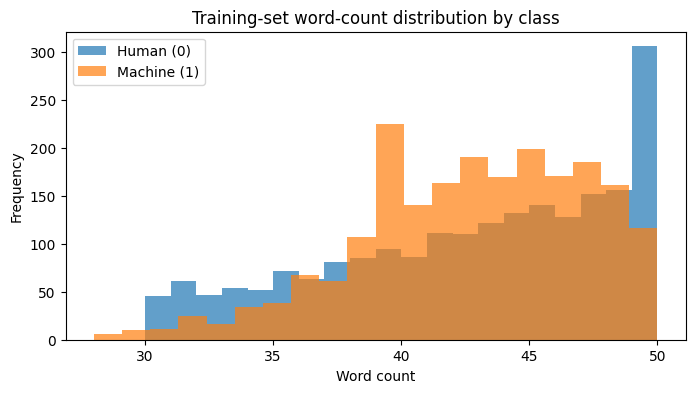

In [8]:
# Word-count distribution by class
plt.figure(figsize=(8, 4))
plt.hist(train_df.loc[train_df['label'] == 0, 'word_count'], bins=20, alpha=0.7, label='Human (0)')
plt.hist(train_df.loc[train_df['label'] == 1, 'word_count'], bins=20, alpha=0.7, label='Machine (1)')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.title('Training-set word-count distribution by class')
plt.legend()
plt.show()


# Data Analysis


### Classical NLP pipeline

This section extracts token and n-gram features, trains statistical classifiers, compares multiple feature settings, and analyses model weights to explain which textual patterns are most associated with each class.


I preprocessed the text by converting it to lowercase and removing extra whitespace. The cleaned text is then stored in a new clean_text column for the training, validation, and test sets, and the label columns are separated for later model training and evaluation.

In [9]:

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for split_df in [train_df, val_df, test_df]:
    split_df['clean_text'] = split_df['text'].apply(clean_text)

y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

print(train_df[['text', 'clean_text', 'label']].head(3))


                                                text  \
0  Elow set down the mandolin near the courtyard ...   
1  "You hear the wind in everything," Aren said. ...   
2  Some secrets are too dangerous to share, even ...   

                                          clean_text  label  
0  elow set down the mandolin near the courtyard ...      1  
1  "you hear the wind in everything," aren said. ...      1  
2  some secrets are too dangerous to share, even ...      0  


I created three different feature extraction methods for the traditional models: Binary Bag-of-Words (1–2 grams), TF-IDF (1 gram), and TF-IDF (1–2 grams). I fitted each vectorizer on the training data and transformed the validation and test sets using the same learned vocabulary so that the different feature settings could be compared consistently.

In [10]:
# Feature extractors
vectorizers = {
    'Binary Bag-of-Words (1-2 grams)': CountVectorizer(
        binary=True,
        ngram_range=(1, 2),
        stop_words='english',
        max_features=5000,
    ),
    'TF-IDF (1 gram)': TfidfVectorizer(
        ngram_range=(1, 1),
        stop_words='english',
        max_features=5000,
    ),
    'TF-IDF (1-2 grams)': TfidfVectorizer(
        ngram_range=(1, 2),
        stop_words='english',
        max_features=5000,
    ),
}

traditional_features = {}
for name, vectorizer in vectorizers.items():
    X_train = vectorizer.fit_transform(train_df['clean_text'])
    X_val = vectorizer.transform(val_df['clean_text'])
    X_test = vectorizer.transform(test_df['clean_text'])
    traditional_features[name] = {
        'vectorizer': vectorizer,
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
    }

list(traditional_features.keys())


['Binary Bag-of-Words (1-2 grams)', 'TF-IDF (1 gram)', 'TF-IDF (1-2 grams)']

I created a function to calculate evaluation metrics and another function to train and test a logistic regression model. I then trained one logistic regression model for each feature extraction method, recorded their validation and test results, and stored the results in a table so I could compare their performance.

In [11]:

def evaluate_predictions(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def fit_logistic_model(X_train, y_train, X_val, y_val, X_test, y_test, c_value=1.0):
    model = LogisticRegression(max_iter=1500, random_state=SEED, C=c_value)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_metrics = evaluate_predictions(y_val, val_pred)
    test_metrics = evaluate_predictions(y_test, test_pred)

    return model, val_pred, test_pred, val_metrics, test_metrics


traditional_results = []
trained_traditional_models = {}

for name, features in traditional_features.items():
    model, val_pred, test_pred, val_metrics, test_metrics = fit_logistic_model(
        features['X_train'], y_train,
        features['X_val'], y_val,
        features['X_test'], y_test,
    )

    trained_traditional_models[name] = {
        'model': model,
        'val_pred': val_pred,
        'test_pred': test_pred,
        'vectorizer': features['vectorizer'],
    }

    traditional_results.append({
        'model': name,
        'val_accuracy': val_metrics['accuracy'],
        'val_f1': val_metrics['f1'],
        'test_accuracy': test_metrics['accuracy'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
    })

traditional_results_df = pd.DataFrame(traditional_results).sort_values(
    by=['val_f1', 'test_f1'], ascending=False
).reset_index(drop=True)
traditional_results_df.to_csv('traditional_model_results.csv', index=False)
traditional_results_df


,model,val_accuracy,val_f1,test_accuracy,test_precision,test_recall,test_f1
0,TF-IDF (1 gram),1.0,1.0,0.998889,1.0,0.997778,0.998888
1,TF-IDF (1-2 grams),1.0,1.0,0.998889,1.0,0.997778,0.998888
2,Binary Bag-of-Words (1-2 grams),1.0,1.0,0.997778,1.0,0.995556,0.997773


Best traditional model: TF-IDF (1 gram)
              precision    recall  f1-score   support

           0     0.9978    1.0000    0.9989       450
           1     1.0000    0.9978    0.9989       450

    accuracy                         0.9989       900
   macro avg     0.9989    0.9989    0.9989       900
weighted avg     0.9989    0.9989    0.9989       900



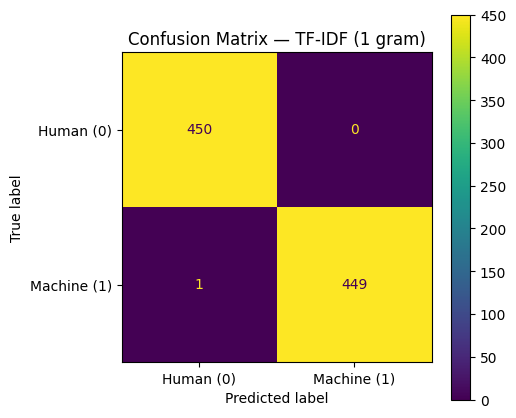

In [12]:

# Detailed report for the best traditional model
best_traditional_name = traditional_results_df.iloc[0]['model']
print('Best traditional model:', best_traditional_name)

best_traditional = trained_traditional_models[best_traditional_name]
print(classification_report(y_test, best_traditional['test_pred'], digits=4))

cm = confusion_matrix(y_test, best_traditional['test_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human (0)', 'Machine (1)'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format='d')
plt.title(f'Confusion Matrix — {best_traditional_name}')
plt.show()


In [13]:
# Analysing the strongest weighted features in the best traditional model
best_vectorizer = best_traditional['vectorizer']
best_model = best_traditional['model']

feature_names = best_vectorizer.get_feature_names_out()
weights = best_model.coef_[0]
feature_df = pd.DataFrame({'feature': feature_names, 'weight': weights})

top_machine = feature_df.sort_values('weight', ascending=False).head(20)
top_human = feature_df.sort_values('weight', ascending=True).head(20)

print('Top features indicating machine-generated text:')
display(top_machine)
print('\nTop features indicating human-written text:')
display(top_human)


Top features indicating machine-generated text:


,feature,weight
1626,glanced,4.891839
4760,waited,3.691913
4894,wind,3.177584
2888,near,3.134913
4975,yard,2.843735
2845,muttered,2.826467
3606,room,2.810066
1841,hidden,2.739416
746,coat,2.729481
576,careful,2.718662



Top features indicating human-written text:


,feature,weight
1124,don,-1.443094
2133,know,-1.378997
2396,lord,-1.371448
2068,just,-1.264829
4817,way,-1.221423
2357,ll,-1.184100
1373,father,-1.133471
1331,eyes,-1.110145
3782,ser,-1.092848
1764,hands,-0.977515


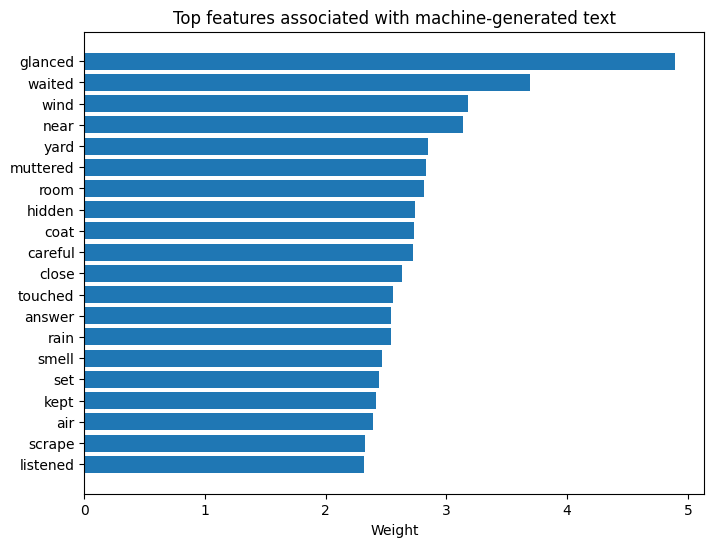

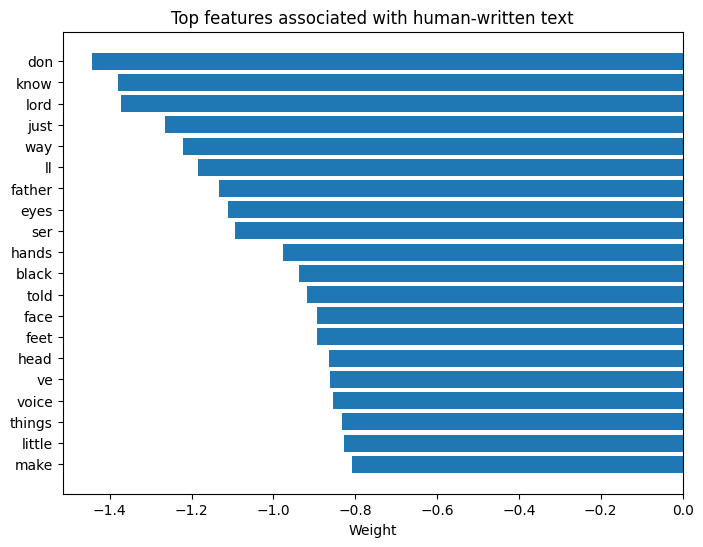

In [14]:

# Visualise the top weighted features
plot_machine = top_machine.sort_values('weight', ascending=True)
plot_human = top_human.sort_values('weight', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(plot_machine['feature'], plot_machine['weight'])
plt.xlabel('Weight')
plt.title('Top features associated with machine-generated text')
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(plot_human['feature'], plot_human['weight'])
plt.xlabel('Weight')
plt.title('Top features associated with human-written text')
plt.show()


### Discussion

I used logistic regression to classify texts as human-written or machine-generated. I compared three feature extraction settings: Binary Bag-of-Words (1–2 grams), TF-IDF (1 gram), and TF-IDF (1–2 grams). Performance was evaluated using accuracy, precision, recall, and F1-score.

All three models performed very well, but the TF-IDF models gave the best results. Both TF-IDF (1 gram) and TF-IDF (1–2 grams) achieved perfect validation scores and reached a test accuracy of 0.998889 with a test F1-score of 0.998888. The Binary Bag-of-Words model was slightly worse, with a test accuracy of 0.997778 and a test F1-score of 0.997773. This suggests that TF-IDF was more effective than simple word presence, because it weights more informative terms more highly.

The first comparison experiment was between Binary Bag-of-Words and TF-IDF. TF-IDF performed slightly better, showing that weighted term importance helped the classifier. The second comparison was between TF-IDF with unigrams only and TF-IDF with unigrams plus bigrams. Both produced the same results, which suggests that unigram features alone were already enough to separate the two classes, and adding bigrams did not improve performance.

A possible reason for the near perfect scores is that the human and machine texts in this dataset may contain clear surface level differences. The machine-generated texts appear to repeat certain descriptive words and narrative patterns, while the human-written texts contain more natural dialogue, contractions, and story-specific vocabulary. Because of this, the classifier may be learning easy lexical cues rather than deeper differences between human and machine writing. This makes the task easier for the model, but it also means the results may not fully reflect real-world AI text detection, where the differences are often more subtle.

To understand the model further, I analysed the logistic regression feature weights. Words such as glanced, waited, wind, near, and muttered were strongly associated with machine-generated text, suggesting repeated descriptive and atmospheric language. In contrast, words such as know, lord, father, eyes, ser, and voice were more associated with human-written text, suggesting more natural dialogue and character-focused wording. Tokens like don, ll, and ve also appeared on the human side, reflecting contractions.

# Classification


### Deep learning models

This section implements three text classifiers and compares them on the validation and test sets:

1. **Mean Embedding Classifier** — a lightweight baseline using masked average pooling.

2. **BiLSTM Classifier** — a stronger sequential model that can capture word order and context.

3. **DistilBERT** — a pre-trained transformer model fine-tuned for text classification.

The Mean Embedding and BiLSTM models use the same PyTorch training, validation, and testing pipeline with early stopping, while DistilBERT is fine-tuned separately using the same data splits for a fair comparison.


I created the tokenisation and vocabulary setup for the deep learning models. I defined special tokens for padding and unknown words, tokenised the training text, and built a vocabulary from the training set based on word frequency so the text could be converted into numerical input for the models.

In [15]:

# Tokenisation and vocabulary
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]")
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_LEN = 80
BATCH_SIZE = 64


def tokenize(text: str):
    return TOKEN_PATTERN.findall(str(text).lower())


def build_vocab(texts, max_vocab_size=20000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab_items = [item for item in counter.items() if item[1] >= min_freq]
    vocab_items = sorted(vocab_items, key=lambda x: (-x[1], x[0]))[: max_vocab_size - 2]

    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, _ in vocab_items:
        stoi[token] = len(stoi)

    return stoi


stoi = build_vocab(train_df['clean_text'], max_vocab_size=MAX_VOCAB_SIZE, min_freq=MIN_FREQ)
itos = {idx: token for token, idx in stoi.items()}

print('Vocabulary size:', len(stoi))


Vocabulary size: 14


I converted the cleaned text into sequences of token IDs and created a custom dataset for text classification. I also defined a collate function to pad sequences within each batch and then built the training, validation, and test data loaders for the deep learning models.

In [16]:

def encode_text(text: str, stoi, max_len=80):
    tokens = tokenize(text)
    ids = [stoi.get(token, stoi[UNK_TOKEN]) for token in tokens[:max_len]]
    return torch.tensor(ids, dtype=torch.long)


class TextClassificationDataset(Dataset):
    def __init__(self, dataframe, stoi, max_len=80):
        self.texts = dataframe['clean_text'].tolist()
        self.labels = dataframe['label'].astype(int).tolist()
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_tensor = encode_text(self.texts[idx], self.stoi, self.max_len)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return text_tensor, label_tensor


def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(x) for x in texts], dtype=torch.long)
    padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return padded, lengths, labels


train_dataset = TextClassificationDataset(train_df, stoi, max_len=MAX_LEN)
val_dataset = TextClassificationDataset(val_df, stoi, max_len=MAX_LEN)
test_dataset = TextClassificationDataset(test_df, stoi, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

first_batch = next(iter(train_loader))
print('Batch shapes:', first_batch[0].shape, first_batch[1].shape, first_batch[2].shape)


Batch shapes: torch.Size([64, 24]) torch.Size([64]) torch.Size([64])


I defined the two deep learning models below. I created a Mean Embedding classifier as a simple baseline that averages word embeddings, and a BiLSTM classifier as a stronger sequence model that can learn contextual information from word order.

In [17]:

class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, dropout=0.3, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        mask = (input_ids != 0).unsqueeze(-1)
        embedded = embedded * mask
        summed = embedded.sum(dim=1)
        lengths = lengths.clamp(min=1).unsqueeze(1)
        pooled = summed / lengths
        pooled = self.dropout(pooled)
        return self.fc(pooled)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed_output, (hidden, cell) = self.lstm(embedded)
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        final_hidden = self.dropout(final_hidden)
        return self.fc(final_hidden)


I defined the training and evaluation workflow for the deep learning models. I created functions to run one epoch, train the model while monitoring validation performance with early stopping, and evaluate the final model on a selected data split using standard classification metrics.

In [18]:

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for input_ids, lengths, labels in dataloader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = evaluate_predictions(all_labels, all_preds)
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, lr=1e-3, epochs=8, patience=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_loss = float('inf')
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_metrics, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_accuracy': train_metrics['accuracy'],
            'val_accuracy': val_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'val_f1': val_metrics['f1'],
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['f1']:.4f} val_f1={val_metrics['f1']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def evaluate_model_on_split(model, dataloader, split_name='test'):
    criterion = nn.CrossEntropyLoss()
    loss, metrics, preds, labels = run_epoch(model, dataloader, criterion, optimizer=None)
    print(f"{split_name.capitalize()} loss: {loss:.4f}")
    print(f"{split_name.capitalize()} accuracy: {metrics['accuracy']:.4f}")
    print(f"{split_name.capitalize()} precision: {metrics['precision']:.4f}")
    print(f"{split_name.capitalize()} recall: {metrics['recall']:.4f}")
    print(f"{split_name.capitalize()} F1: {metrics['f1']:.4f}")
    return loss, metrics, preds, labels


In [19]:

# Model 1: Mean Embedding baseline
mean_model = MeanEmbeddingClassifier(vocab_size=len(stoi), embed_dim=128, dropout=0.3).to(device)
mean_model, mean_history = train_model(mean_model, train_loader, val_loader, lr=1e-3, epochs=8, patience=2)

mean_val_loss, mean_val_metrics, _, _ = evaluate_model_on_split(mean_model, val_loader, split_name='validation')
mean_test_loss, mean_test_metrics, mean_test_preds, mean_test_labels = evaluate_model_on_split(mean_model, test_loader, split_name='test')


Epoch 01 | train_loss=0.6217 val_loss=0.5952 | train_f1=0.6911 val_f1=0.7227
Epoch 02 | train_loss=0.5783 val_loss=0.5808 | train_f1=0.7204 val_f1=0.7271
Epoch 03 | train_loss=0.5682 val_loss=0.5752 | train_f1=0.7283 val_f1=0.7267
Epoch 04 | train_loss=0.5673 val_loss=0.5697 | train_f1=0.7407 val_f1=0.7188
Epoch 05 | train_loss=0.5611 val_loss=0.5660 | train_f1=0.7365 val_f1=0.7157
Epoch 06 | train_loss=0.5601 val_loss=0.5658 | train_f1=0.7434 val_f1=0.7253
Epoch 07 | train_loss=0.5576 val_loss=0.5682 | train_f1=0.7442 val_f1=0.7206
Epoch 08 | train_loss=0.5553 val_loss=0.5635 | train_f1=0.7349 val_f1=0.7259
Validation loss: 0.5635
Validation accuracy: 0.7256
Validation precision: 0.7251
Validation recall: 0.7267
Validation F1: 0.7259
Test loss: 0.5629
Test accuracy: 0.7289
Test precision: 0.7239
Test recall: 0.7400
Test F1: 0.7319


In [20]:

# Model 2: BiLSTM
bilstm_model = BiLSTMClassifier(vocab_size=len(stoi), embed_dim=128, hidden_dim=128, dropout=0.3).to(device)
bilstm_model, bilstm_history = train_model(bilstm_model, train_loader, val_loader, lr=1e-3, epochs=8, patience=2)

bilstm_val_loss, bilstm_val_metrics, _, _ = evaluate_model_on_split(bilstm_model, val_loader, split_name='validation')
bilstm_test_loss, bilstm_test_metrics, bilstm_test_preds, bilstm_test_labels = evaluate_model_on_split(bilstm_model, test_loader, split_name='test')


Epoch 01 | train_loss=0.5308 val_loss=0.4227 | train_f1=0.7092 val_f1=0.8224
Epoch 02 | train_loss=0.3882 val_loss=0.3432 | train_f1=0.8248 val_f1=0.8556
Epoch 03 | train_loss=0.3181 val_loss=0.3033 | train_f1=0.8634 val_f1=0.8722
Epoch 04 | train_loss=0.2695 val_loss=0.2705 | train_f1=0.8871 val_f1=0.8927
Epoch 05 | train_loss=0.2445 val_loss=0.2391 | train_f1=0.9000 val_f1=0.9010
Epoch 06 | train_loss=0.2385 val_loss=0.2378 | train_f1=0.8983 val_f1=0.9041
Epoch 07 | train_loss=0.2246 val_loss=0.2347 | train_f1=0.9100 val_f1=0.9081
Epoch 08 | train_loss=0.2142 val_loss=0.2401 | train_f1=0.9134 val_f1=0.9036
Validation loss: 0.2347
Validation accuracy: 0.9067
Validation precision: 0.8944
Validation recall: 0.9222
Validation F1: 0.9081
Test loss: 0.2540
Test accuracy: 0.8978
Test precision: 0.8792
Test recall: 0.9222
Test F1: 0.9002


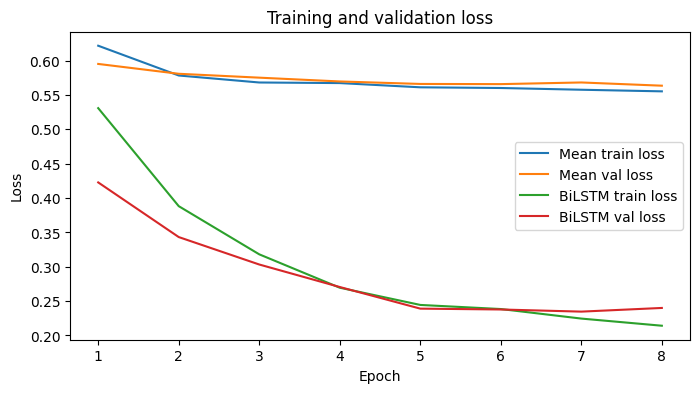

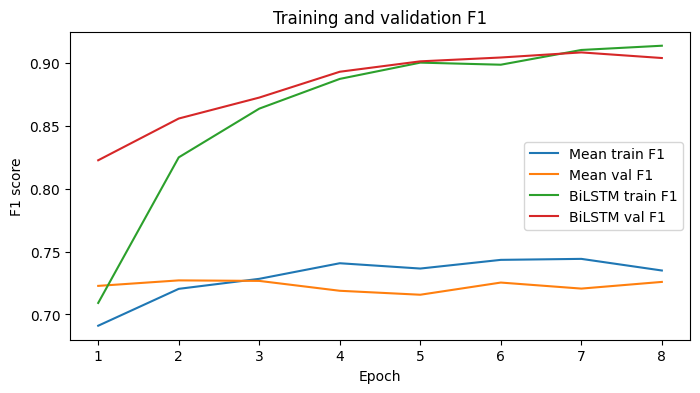

In [21]:

# Plot training curves for both neural models
plt.figure(figsize=(8, 4))
plt.plot(mean_history['epoch'], mean_history['train_loss'], label='Mean train loss')
plt.plot(mean_history['epoch'], mean_history['val_loss'], label='Mean val loss')
plt.plot(bilstm_history['epoch'], bilstm_history['train_loss'], label='BiLSTM train loss')
plt.plot(bilstm_history['epoch'], bilstm_history['val_loss'], label='BiLSTM val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mean_history['epoch'], mean_history['train_f1'], label='Mean train F1')
plt.plot(mean_history['epoch'], mean_history['val_f1'], label='Mean val F1')
plt.plot(bilstm_history['epoch'], bilstm_history['train_f1'], label='BiLSTM train F1')
plt.plot(bilstm_history['epoch'], bilstm_history['val_f1'], label='BiLSTM val F1')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.title('Training and validation F1')
plt.legend()
plt.show()


The loss curves show that the BiLSTM trained more effectively, with both training and validation loss generally decreasing over the epochs. The Mean Embedding model also improved, but its validation loss remained higher, suggesting weaker learning and poorer generalisation.

The F1 curves show that the BiLSTM achieved much stronger performance on both the training and validation sets. Its validation F1 increased steadily and remained much higher than the Mean Embedding model, indicating that it captured the text patterns more effectively.

Moving on, I added a pre-trained DistilBERT model for sequence classification. I tokenised the text with the DistilBERT tokenizer, fine-tuned the model on the training set, monitored validation performance during training, and evaluated the final model on the validation and test sets.


In [22]:
# DistilBERT dataset and setup
DISTILBERT_NAME = 'distilbert-base-uncased'
MAX_LEN_BERT = 128
BATCH_SIZE_BERT = 16
LEARNING_RATE_BERT = 2e-5
EPOCHS_BERT = 3
PATIENCE_BERT = 2

bert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_NAME)


class DistilBERTDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.texts = dataframe['clean_text'].tolist()
        self.labels = dataframe['label'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_bert_dataset = DistilBERTDataset(train_df, bert_tokenizer, max_len=MAX_LEN_BERT)
val_bert_dataset = DistilBERTDataset(val_df, bert_tokenizer, max_len=MAX_LEN_BERT)
test_bert_dataset = DistilBERTDataset(test_df, bert_tokenizer, max_len=MAX_LEN_BERT)

train_bert_loader = DataLoader(train_bert_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
val_bert_loader = DataLoader(val_bert_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)
test_bert_loader = DataLoader(test_bert_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)

first_bert_batch = next(iter(train_bert_loader))
print('DistilBERT batch shapes:', first_bert_batch['input_ids'].shape, first_bert_batch['attention_mask'].shape, first_bert_batch['labels'].shape)


DistilBERT batch shapes: torch.Size([16, 128]) torch.Size([16, 128]) torch.Size([16])


In [23]:
def run_epoch_distilbert(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss
            logits = outputs.logits

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = evaluate_predictions(all_labels, all_preds)
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_distilbert(model, train_loader, val_loader, lr=2e-5, epochs=3, patience=2):
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    best_state = None
    best_val_loss = float('inf')
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics, _, _ = run_epoch_distilbert(model, train_loader, optimizer)
        val_loss, val_metrics, _, _ = run_epoch_distilbert(model, val_loader, optimizer=None)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_accuracy': train_metrics['accuracy'],
            'val_accuracy': val_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'val_f1': val_metrics['f1'],
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['f1']:.4f} val_f1={val_metrics['f1']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def evaluate_distilbert_on_split(model, dataloader, split_name='test'):
    loss, metrics, preds, labels = run_epoch_distilbert(model, dataloader, optimizer=None)
    print(f"{split_name.capitalize()} loss: {loss:.4f}")
    print(f"{split_name.capitalize()} accuracy: {metrics['accuracy']:.4f}")
    print(f"{split_name.capitalize()} precision: {metrics['precision']:.4f}")
    print(f"{split_name.capitalize()} recall: {metrics['recall']:.4f}")
    print(f"{split_name.capitalize()} F1: {metrics['f1']:.4f}")
    return loss, metrics, preds, labels


In [24]:
# Model 3: DistilBERT
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=2,
).to(device)

distilbert_model, distilbert_history = train_distilbert(
    distilbert_model,
    train_bert_loader,
    val_bert_loader,
    lr=LEARNING_RATE_BERT,
    epochs=EPOCHS_BERT,
    patience=PATIENCE_BERT,
)

distilbert_val_loss, distilbert_val_metrics, _, _ = evaluate_distilbert_on_split(
    distilbert_model, val_bert_loader, split_name='validation'
)
distilbert_test_loss, distilbert_test_metrics, distilbert_test_preds, distilbert_test_labels = evaluate_distilbert_on_split(
    distilbert_model, test_bert_loader, split_name='test'
)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5734.78it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | train_loss=0.0789 val_loss=0.0027 | train_f1=0.9696 val_f1=1.0000
Epoch 02 | train_loss=0.0011 val_loss=0.0004 | train_f1=1.0000 val_f1=1.0000
Epoch 03 | train_loss=0.0003 val_loss=0.0002 | train_f1=1.0000 val_f1=1.0000
Validation loss: 0.0002
Validation accuracy: 1.0000
Validation precision: 1.0000
Validation recall: 1.0000
Validation F1: 1.0000
Test loss: 0.0002
Test accuracy: 1.0000
Test precision: 1.0000
Test recall: 1.0000
Test F1: 1.0000


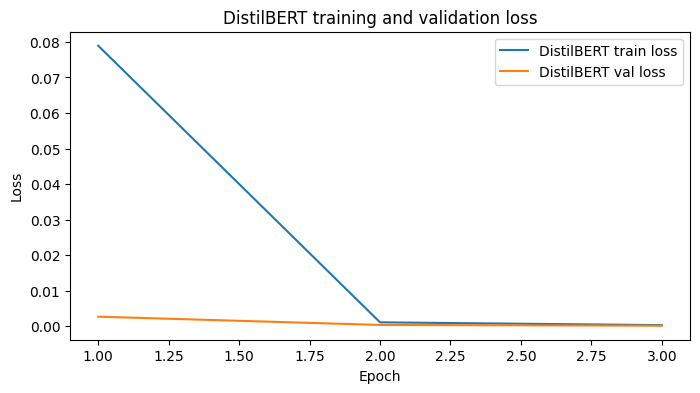

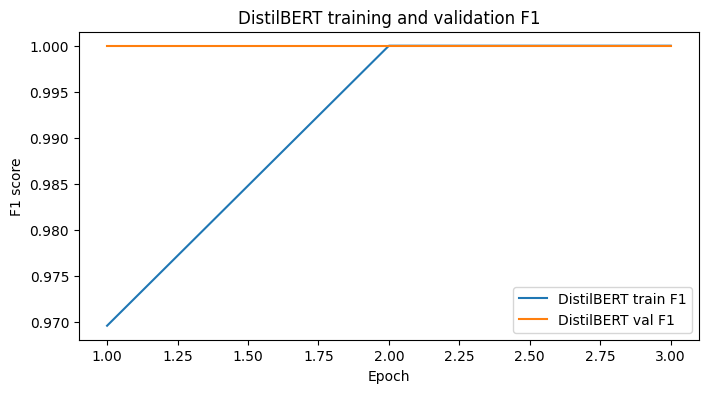

In [25]:
# Plot training curves for DistilBERT
plt.figure(figsize=(8, 4))
plt.plot(distilbert_history['epoch'], distilbert_history['train_loss'], label='DistilBERT train loss')
plt.plot(distilbert_history['epoch'], distilbert_history['val_loss'], label='DistilBERT val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DistilBERT training and validation loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(distilbert_history['epoch'], distilbert_history['train_f1'], label='DistilBERT train F1')
plt.plot(distilbert_history['epoch'], distilbert_history['val_f1'], label='DistilBERT val F1')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.title('DistilBERT training and validation F1')
plt.legend()
plt.show()


The DistilBERT training curves show very fast and stable learning. Both training and validation loss dropped sharply across the three epochs, while the training F1 increased to 1.0 and the validation F1 remained perfect throughout training. This suggests that DistilBERT adapted to the task very quickly, but it may also indicate that the dataset contains strong, easy-to-learn differences between the two classes.

In [26]:
# Deep-learning comparison table
nn_results_df = pd.DataFrame([
    {
        'model': 'Mean Embedding',
        'val_accuracy': mean_val_metrics['accuracy'],
        'val_f1': mean_val_metrics['f1'],
        'test_accuracy': mean_test_metrics['accuracy'],
        'test_precision': mean_test_metrics['precision'],
        'test_recall': mean_test_metrics['recall'],
        'test_f1': mean_test_metrics['f1'],
    },
    {
        'model': 'BiLSTM',
        'val_accuracy': bilstm_val_metrics['accuracy'],
        'val_f1': bilstm_val_metrics['f1'],
        'test_accuracy': bilstm_test_metrics['accuracy'],
        'test_precision': bilstm_test_metrics['precision'],
        'test_recall': bilstm_test_metrics['recall'],
        'test_f1': bilstm_test_metrics['f1'],
    },
    {
        'model': 'DistilBERT',
        'val_accuracy': distilbert_val_metrics['accuracy'],
        'val_f1': distilbert_val_metrics['f1'],
        'test_accuracy': distilbert_test_metrics['accuracy'],
        'test_precision': distilbert_test_metrics['precision'],
        'test_recall': distilbert_test_metrics['recall'],
        'test_f1': distilbert_test_metrics['f1'],
    },
]).sort_values(by=['val_f1', 'test_f1'], ascending=False).reset_index(drop=True)

nn_results_df

,model,val_accuracy,val_f1,test_accuracy,test_precision,test_recall,test_f1
0,DistilBERT,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,BiLSTM,0.906667,0.908096,0.897778,0.879237,0.922222,0.900217
2,Mean Embedding,0.725556,0.725860,0.728889,0.723913,0.740000,0.731868


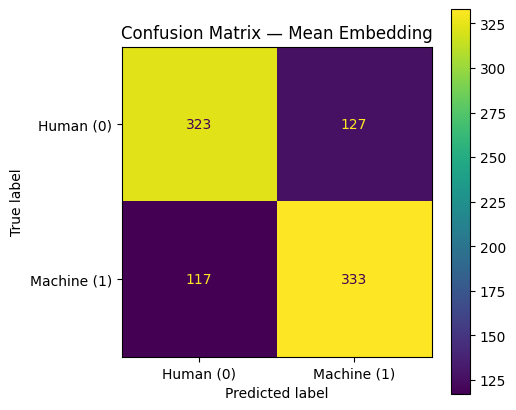

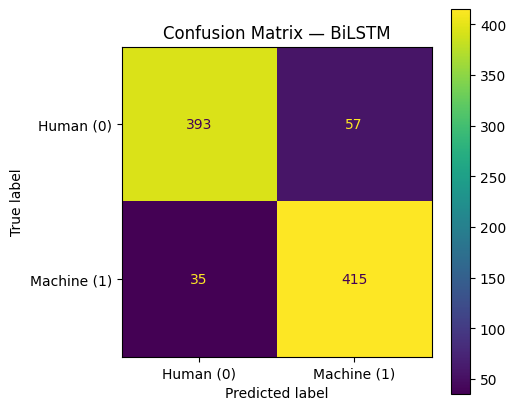

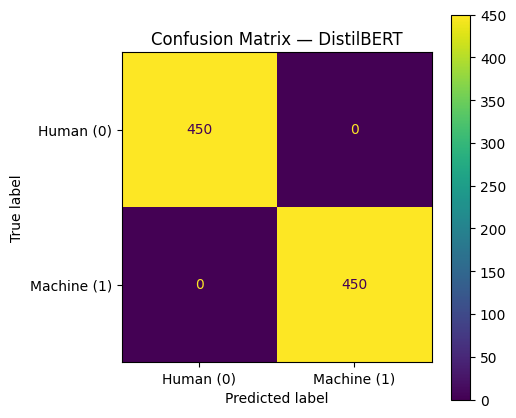

In [27]:
# Confusion matrices for all neural models
neural_predictions = {
    'Mean Embedding': mean_test_preds,
    'BiLSTM': bilstm_test_preds,
    'DistilBERT': distilbert_test_preds,
}

for model_name, preds in neural_predictions.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Human (0)', 'Machine (1)']
    )
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format='d')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

### Discussion

In this part, I implemented and compared three neural models for classifying human-written and machine-generated text: a Mean Embedding model, a BiLSTM, and DistilBERT. The Mean Embedding model was used as a simple baseline, the BiLSTM was used as a sequence model that can capture word order and context, and DistilBERT was included as a pre-trained transformer model. All three models were trained using a validation set, and their learning progress was monitored with training and validation loss and F1-score.

The results showed clear differences between the models. The Mean Embedding model performed the weakest, with a test F1-score of 0.731868, which suggests that simply averaging word embeddings was not enough to capture the important patterns in the dataset. The BiLSTM performed much better, achieving a test F1-score of 0.900217, because it processes the text as a sequence and can learn contextual information from word order. The BiLSTM also had a higher test recall (0.922222) than precision (0.879237), which means it was slightly better at identifying machine-generated texts than avoiding false positives. In other words, it caught most machine-generated examples, but it also misclassified some human-written texts as machine-generated. DistilBERT performed the best by a large margin, reaching perfect validation and test scores, with 1.000000 accuracy and 1.000000 F1 on both sets. This shows that the pre-trained transformer was able to separate the two classes extremely effectively.

The training curves also reflect these differences. The Mean Embedding model improved only slightly and stayed at a relatively low validation F1, suggesting that it was too simple for the task. The BiLSTM showed much stronger learning, with lower validation loss and much higher validation F1 over time. DistilBERT converged very quickly, with both training and validation loss dropping close to zero. Its training F1 increased to 1.0, while its validation F1 remained at 1.0 throughout training. This suggests that the pre-trained model adapted very easily to the classification task.

Compared with the other neural models, DistilBERT was clearly the strongest approach because it starts with rich language knowledge learned from large-scale pre-training. This gives it a major advantage over models that learn only from the assignment dataset. At the same time, the perfect DistilBERT scores suggest that the dataset may contain patterns that are especially easy for a strong language model to separate.

Traditional feature-based models were also very strong, but DistilBERT ultimately outperformed them. A likely reason is that the dataset contains clear lexical cues, which explains why TF-IDF and Bag-of-Words performed so well, while DistilBERT was able to make even better use of these patterns through its pre-trained contextual representations. However, the perfect validation and test scores also suggest that the dataset may be easier than a more realistic human-versus-AI classification task.
